# 10 — Regression intra-zone : prediction des coordonnees (x, y)

Conforme au cahier des charges IF23 P (page 5) :
- **Entree** : vecteur de N RSSIs par BSSID.
- **Sortie** : coordonnees (x, y) dans le repere de la zone.
- **Dataset** : 30+ points de mesures dans une zone, 5 mesures par point puis moyennees.

On suit les etapes du PDF (page 6) :
1. Etude des donnees (couverture des reseaux, sparsite, correlation).
2. Split train/test aleatoire.
3. Plusieurs modeles **avec tous les reseaux** puis **avec une selection** des BSSID.
4. Evaluation des performances en regression.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')

_SRC = (Path.cwd().parent / 'src').resolve()
if str(_SRC) not in sys.path:
    sys.path.insert(0, str(_SRC))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from intra_zone_regression import (
    load_regression_dataset, build_model_zoo, evaluate_models,
    select_top_bssids, IntraZoneRegressor, save_regression_artifacts,
)

CSV_PATH = Path('../data/regression/dataset_regression.csv')
OUT_DIR = Path('../models/artifacts_regression')

## 1. Chargement et exploration

In [2]:
X, y, bssids = load_regression_dataset(CSV_PATH)
print(f'Dataset : {X.shape[0]} points × {len(bssids)} BSSID')
print(f'Plage X : [{y[:, 0].min():.1f}, {y[:, 0].max():.1f}] m')
print(f'Plage Y : [{y[:, 1].min():.1f}, {y[:, 1].max():.1f}] m')
print(f'Surface zone : {(y[:, 0].max() - y[:, 0].min()):.1f} × {(y[:, 1].max() - y[:, 1].min()):.1f} m')
X.head()

Dataset : 46 points × 52 BSSID
Plage X : [-1.0, 4.0] m
Plage Y : [0.0, 7.0] m
Surface zone : 5.0 × 7.0 m


,ac:2a:a1:7e:df:61,ac:2a:a1:7e:df:62,ac:2a:a1:7e:df:65,ac:2a:a1:7e:df:67,ac:2a:a1:7e:df:68,ac:2a:a1:7e:df:6a,ac:2a:a1:7e:df:6d,ac:2a:a1:7e:df:6e,e4:aa:5d:bf:25:51,e4:aa:5d:bf:25:52,...,f8:6b:d9:01:93:68,f8:6b:d9:01:93:6a,f8:6b:d9:95:d8:81,f8:6b:d9:95:d8:82,f8:6b:d9:95:d8:85,f8:6b:d9:95:d8:87,f8:6b:d9:95:d8:88,f8:6b:d9:95:d8:8a,f8:6b:d9:95:d8:8d,f8:6b:d9:95:d8:8e
0,-75.50,-75.50,-73.500,-73.625,-73.625,-73.500,-71.5,-71.5,0.0,0.00,...,0.0,0.0,-78.0,-81.50,-83.750,-81.750,-82.375,-81.875,-84.25,-84.25
1,-75.75,-75.75,-74.125,-74.500,-74.375,-74.375,-73.0,-73.0,-92.5,-92.50,...,0.0,0.0,-81.5,-79.50,-82.250,-81.625,-81.500,-82.000,-84.50,-85.00
2,-74.90,-75.10,-74.250,-74.300,-74.325,-74.025,-74.3,-73.5,-91.9,-94.00,...,0.0,0.0,-75.9,-76.10,-80.000,-82.175,-81.100,-82.025,-84.00,-83.85
3,-76.50,-78.25,-76.750,-74.375,-74.625,-74.375,-70.5,-70.5,-93.0,-92.25,...,0.0,0.0,-79.0,-80.25,-80.125,-80.625,-80.875,-80.375,-82.25,-82.25
4,-80.50,-80.50,-74.250,-75.500,-76.000,-75.750,-69.0,-71.0,-89.0,-90.00,...,0.0,0.0,-80.0,-81.50,-85.250,-83.750,-84.000,-81.875,-85.25,-85.75


In [3]:
# Sparsite : combien de BSSID captes par point en moyenne ?
captured = (X != 0).sum(axis=1)
print(f'BSSID captes par point : min={captured.min()}, max={captured.max()}, moyenne={captured.mean():.1f}')
print(f'Densite globale du vecteur RSSI : {(X != 0).values.mean():.1%}')

# Couverture par BSSID (% des points qui le captent)
coverage = (X != 0).mean(axis=0).sort_values(ascending=False)
print('\nCouverture par BSSID (top 15) :')
print(coverage.head(15).to_string())

BSSID captes par point : min=27, max=50, moyenne=39.1
Densite globale du vecteur RSSI : 75.1%

Couverture par BSSID (top 15) :
ac:2a:a1:7e:df:61    1.0
ac:2a:a1:7e:df:65    1.0
ac:2a:a1:7e:df:67    1.0
ac:2a:a1:7e:df:68    1.0
ac:2a:a1:7e:df:6d    1.0
ac:2a:a1:7e:df:6a    1.0
ac:2a:a1:7e:df:6e    1.0
f8:6b:d9:01:8e:e1    1.0
f8:6b:d9:01:8e:ea    1.0
f8:6b:d9:01:8e:e8    1.0
f8:6b:d9:01:8e:e7    1.0
f8:6b:d9:01:8e:e5    1.0
f8:6b:d9:01:8e:ed    1.0
f8:6b:d9:01:8e:ee    1.0
f8:6b:d9:95:d8:87    1.0


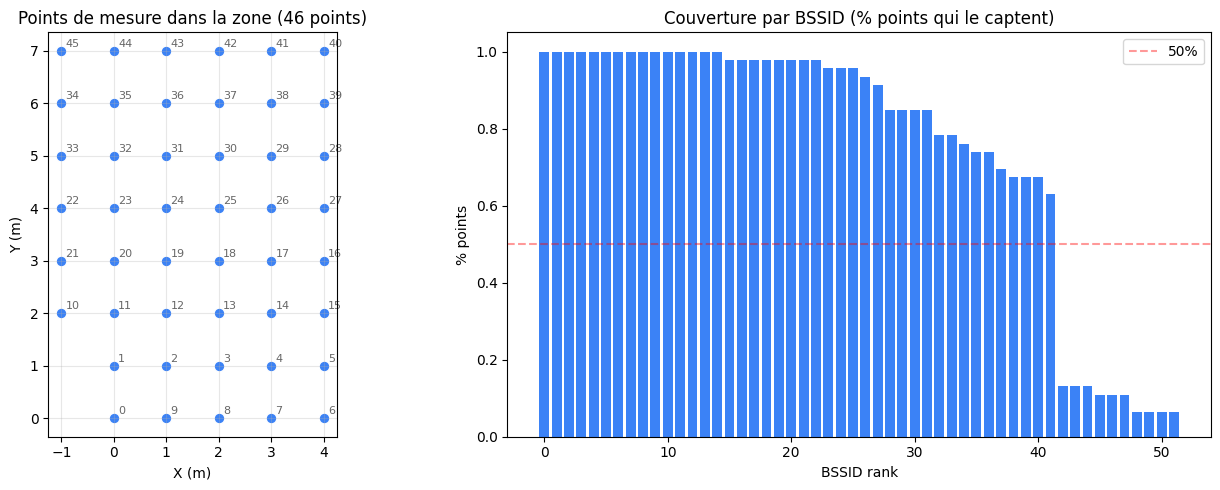

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(y[:, 0], y[:, 1], c='#3b82f6', s=60, edgecolor='white')
for i, (xi, yi) in enumerate(y):
    axes[0].annotate(str(i), (xi, yi), fontsize=8, alpha=0.6,
                      xytext=(3, 3), textcoords='offset points')
axes[0].set_title(f'Points de mesure dans la zone ({len(y)} points)')
axes[0].set_xlabel('X (m)'); axes[0].set_ylabel('Y (m)')
axes[0].grid(alpha=0.3); axes[0].set_aspect('equal')

axes[1].bar(range(len(coverage)), coverage.values, color='#3b82f6')
axes[1].set_title('Couverture par BSSID (% points qui le captent)')
axes[1].set_xlabel('BSSID rank'); axes[1].set_ylabel('% points')
axes[1].axhline(0.5, color='red', linestyle='--', alpha=0.4, label='50%')
axes[1].legend()
plt.tight_layout(); plt.show()

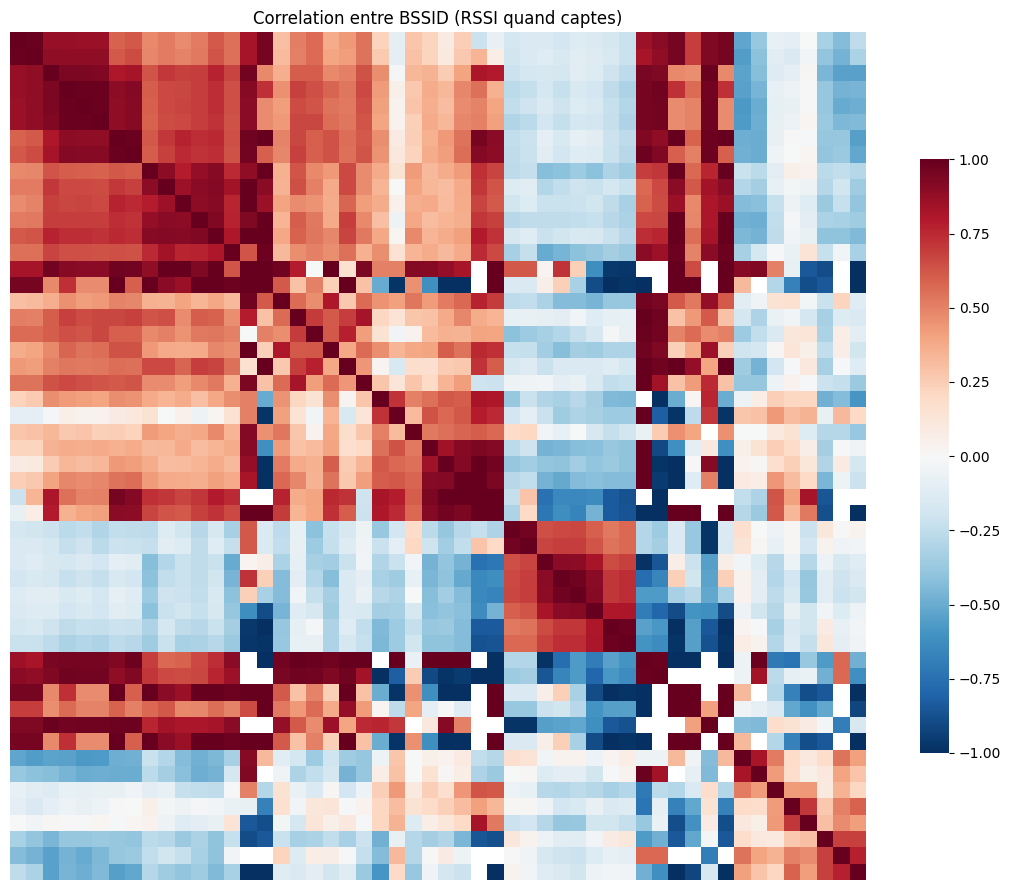

In [5]:
# Correlation entre BSSID (sur les RSSI non-nuls) — interessant pour reperer la redondance.
X_for_corr = X.replace(0, np.nan)
corr = X_for_corr.corr()
fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, ax=ax, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            xticklabels=False, yticklabels=False, cbar_kws={'shrink': 0.7})
ax.set_title('Correlation entre BSSID (RSSI quand captes)')
plt.tight_layout(); plt.show()

## 2. Modeles : **toutes les features** (tous les BSSID)

Hold-out 25%, 8 algorithmes.

In [6]:
zoo = build_model_zoo()
metrics_all, fitted_all, splits = evaluate_models(X, y, zoo, test_size=0.25, random_state=42)
print('Resultats avec toutes les features ({} BSSID):'.format(X.shape[1]))
metrics_all

Resultats avec toutes les features (52 BSSID):


,model,MAE_x,MAE_y,MAE_euclid_m,median_euclid_m,RMSE_euclid_m,R2_x,R2_y
0,ExtraTrees,0.924167,0.645833,1.192361,1.148089,0.985740,0.309215,0.884786
1,RandomForest,0.788611,0.929444,1.314040,1.154791,1.057341,0.442991,0.802850
2,KNN_3,1.298800,0.599588,1.477132,1.392855,1.135874,-0.150456,0.910373
3,GradientBoosting,1.211981,0.604422,1.479510,1.465374,1.126554,-0.149882,0.916789
4,KNN_5,1.219322,0.855270,1.593550,1.447323,1.320753,-0.159012,0.771135
5,Ridge,1.099865,1.158167,1.787441,1.736310,1.353260,0.171315,0.654310
6,MLP_64_32,1.167437,1.316816,1.844122,1.582092,1.441599,0.061631,0.607150
7,LinearRegression,1.490601,1.726913,2.641222,2.365429,2.059420,-1.396099,0.328952


## 3. Selection de BSSID intéressants

On classe les BSSID par feature_importance d'un RandomForest, puis on garde les top-K.

In [7]:
ks = [5, 10, 15, 20, 30]
comp_rows = []
best_metrics_by_k = {}
for k in ks:
    selected = select_top_bssids(X, y, k=k)
    Xk = X[selected]
    metrics_k, fitted_k, _ = evaluate_models(Xk, y, build_model_zoo(),
                                              test_size=0.25, random_state=42)
    best = metrics_k.iloc[0]
    comp_rows.append({
        'k_features': k, 'best_model': best['model'],
        'MAE_euclid_m': best['MAE_euclid_m'],
        'median_m': best['median_euclid_m'],
        'R2_x': best['R2_x'], 'R2_y': best['R2_y'],
    })
    best_metrics_by_k[k] = (metrics_k, fitted_k, selected)
comp_rows.append({'k_features': X.shape[1], 'best_model': metrics_all.iloc[0]['model'],
                   'MAE_euclid_m': metrics_all.iloc[0]['MAE_euclid_m'],
                   'median_m': metrics_all.iloc[0]['median_euclid_m'],
                   'R2_x': metrics_all.iloc[0]['R2_x'],
                   'R2_y': metrics_all.iloc[0]['R2_y']})
comparison = pd.DataFrame(comp_rows).sort_values('MAE_euclid_m').reset_index(drop=True)
comparison

,k_features,best_model,MAE_euclid_m,median_m,R2_x,R2_y
0,52,ExtraTrees,1.192361,1.148089,0.309215,0.884786
1,20,RandomForest,1.343467,1.284589,0.380916,0.812260
2,30,ExtraTrees,1.343732,1.051284,0.245190,0.788094
3,15,RandomForest,1.356775,1.263051,0.331122,0.832467
4,10,RandomForest,1.397741,1.197847,0.214003,0.820091
5,5,Ridge,1.641800,1.542470,-0.429882,0.765926


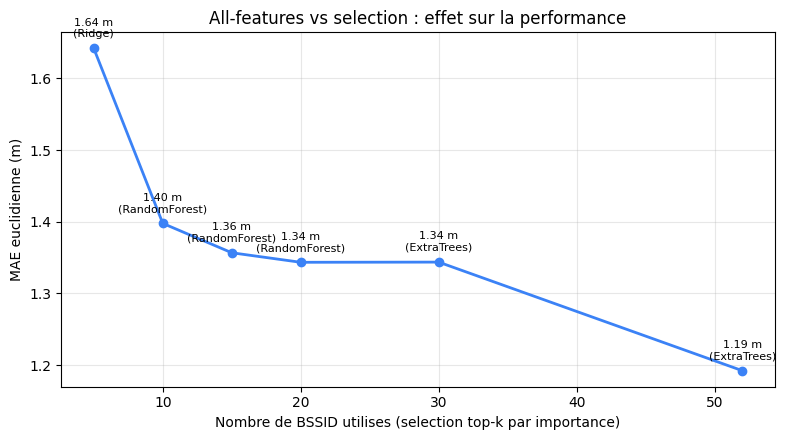

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.5))
comp_sorted = comparison.sort_values('k_features')
ax.plot(comp_sorted['k_features'], comp_sorted['MAE_euclid_m'], 'o-', color='#3b82f6', linewidth=2)
for _, r in comp_sorted.iterrows():
    ax.annotate(f"{r['MAE_euclid_m']:.2f} m\n({r['best_model']})",
                (r['k_features'], r['MAE_euclid_m']),
                fontsize=8, ha='center', xytext=(0, 8), textcoords='offset points')
ax.set_xlabel('Nombre de BSSID utilises (selection top-k par importance)')
ax.set_ylabel('MAE euclidienne (m)')
ax.set_title('All-features vs selection : effet sur la performance')
ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 4. Best model — visualisation des predictions

In [9]:
# Choisir le meilleur global (toutes features ou selection)
best_row = comparison.iloc[0]
best_k = int(best_row['k_features'])
best_model_name = best_row['best_model']
if best_k == X.shape[1]:
    best_X = X
    best_fitted = fitted_all[best_model_name]
    selected_bssids = list(X.columns)
else:
    metrics_k, fitted_k, selected_bssids = best_metrics_by_k[best_k]
    best_X = X[selected_bssids]
    best_fitted = fitted_k[best_model_name]

X_train, X_test, y_train, y_test = (
    splits['X_train'][selected_bssids] if best_k != X.shape[1] else splits['X_train'],
    splits['X_test'][selected_bssids] if best_k != X.shape[1] else splits['X_test'],
    splits['y_train'], splits['y_test'])
y_pred = best_fitted.predict(X_test)
errs = np.sqrt(((y_pred - y_test) ** 2).sum(axis=1))
print(f"Best : {best_model_name} (k={best_k} BSSID)")
print(f"  MAE euclid: {errs.mean():.3f} m")
print(f"  Median   : {np.median(errs):.3f} m")
print(f"  P90      : {np.percentile(errs, 90):.3f} m")
print(f"  Max      : {errs.max():.3f} m")

Best : ExtraTrees (k=52 BSSID)
  MAE euclid: 1.192 m
  Median   : 1.148 m
  P90      : 2.184 m
  Max      : 2.825 m


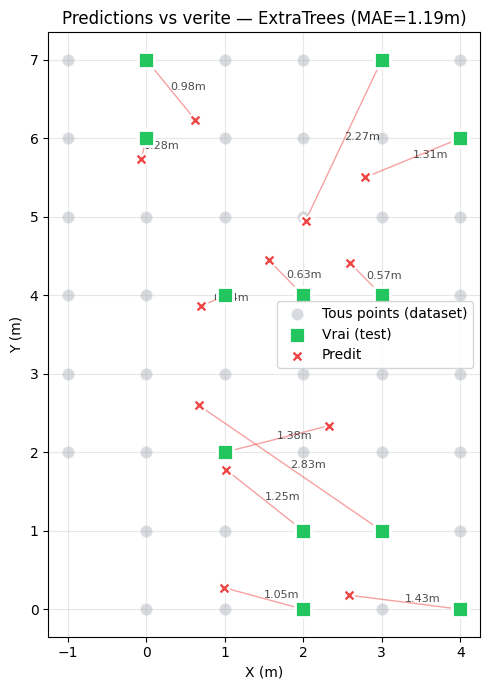

In [10]:
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y[:, 0], y[:, 1], c='#9ca3af', s=80, alpha=0.4,
           edgecolor='white', label='Tous points (dataset)')
ax.scatter(y_test[:, 0], y_test[:, 1], c='#22c55e', s=140, marker='s',
           edgecolor='white', linewidth=2, label='Vrai (test)', zorder=4)
ax.scatter(y_pred[:, 0], y_pred[:, 1], c='#ef4444', s=80, marker='X',
           edgecolor='white', linewidth=1.5, label='Predit', zorder=5)
for true, pred, e in zip(y_test, y_pred, errs):
    ax.plot([true[0], pred[0]], [true[1], pred[1]],
            color='#ef4444', linewidth=1, alpha=0.5)
    ax.annotate(f'{e:.2f}m', ((true[0]+pred[0])/2, (true[1]+pred[1])/2),
                fontsize=8, alpha=0.7)
ax.set_xlabel('X (m)'); ax.set_ylabel('Y (m)')
ax.set_title(f'Predictions vs verite — {best_model_name} (MAE={errs.mean():.2f}m)')
ax.set_aspect('equal'); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout()
OUT_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT_DIR / 'prediction_scatter.png', dpi=150)
plt.show()

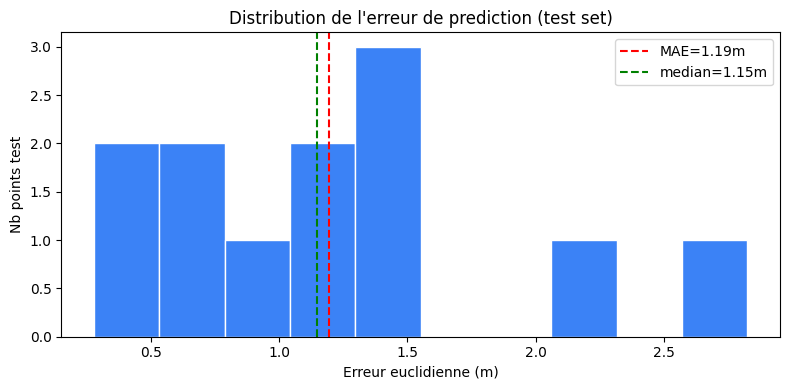

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(errs, bins=10, color='#3b82f6', edgecolor='white')
ax.axvline(errs.mean(), color='red', linestyle='--', label=f'MAE={errs.mean():.2f}m')
ax.axvline(np.median(errs), color='green', linestyle='--', label=f'median={np.median(errs):.2f}m')
ax.set_xlabel('Erreur euclidienne (m)'); ax.set_ylabel('Nb points test')
ax.set_title('Distribution de l\'erreur de prediction (test set)')
ax.legend(); plt.tight_layout(); plt.show()

## 5. Sauvegarde de l'artefact

In [12]:
# Re-fit sur l'ensemble du dataset pour le modele final
from sklearn.base import clone
final_model = clone(zoo[best_model_name] if best_k == X.shape[1] else build_model_zoo()[best_model_name])
final_X = X if best_k == X.shape[1] else X[selected_bssids]
final_model.fit(final_X, y)

regressor = IntraZoneRegressor(
    model=final_model,
    bssid_columns=list(final_X.columns),
    bounds={'x': (float(y[:, 0].min()), float(y[:, 0].max())),
            'y': (float(y[:, 1].min()), float(y[:, 1].max()))},
)
save_regression_artifacts(
    OUT_DIR, regressor, comparison,
    extra_metadata={
        'best_model': best_model_name,
        'best_k_features': int(best_k),
        'best_test_mae_m': float(errs.mean()),
        'best_test_median_m': float(np.median(errs)),
        'best_test_p90_m': float(np.percentile(errs, 90)),
        'best_test_max_m': float(errs.max()),
        'n_points': int(len(y)),
        'n_bssid_total': int(X.shape[1]),
        'source_csv': 'data/regression/dataset_regression.csv',
    },
)
print('Artefacts sauves dans', OUT_DIR.resolve())
print('Contenu:', [p.name for p in OUT_DIR.iterdir()])

Artefacts sauves dans C:\Users\virgi\Documents\UTT_2025\Semestre 4\IF23\IF23_Localisation\models\artifacts_regression
Contenu: ['metadata.json', 'metrics.csv', 'prediction_scatter.png', 'regressor.pkl']


In [13]:
# Test final : prediction depuis un dict {bssid: rssi}
from intra_zone_regression import load_regression_artifacts
loaded = load_regression_artifacts(OUT_DIR)
demo_scan = {bssid: float(X[bssid].iloc[0]) for bssid in regressor.bssid_columns
             if X[bssid].iloc[0] != 0}
x_pred, y_pred_val = loaded.predict(demo_scan)
print(f'Demo : prediction depuis le 1er point du dataset : ({x_pred:.2f}, {y_pred_val:.2f}) m')
print(f'           verite : ({y[0, 0]:.2f}, {y[0, 1]:.2f}) m')
print(f'           erreur : {np.sqrt((x_pred - y[0,0])**2 + (y_pred_val - y[0,1])**2):.3f} m')

Demo : prediction depuis le 1er point du dataset : (0.00, 0.00) m
           verite : (0.00, 0.00) m
           erreur : 0.000 m
